In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

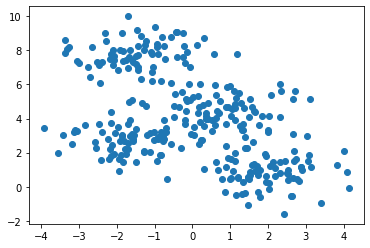

In [2]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.90, 
                       random_state=0)
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('')
plt.show()

In [5]:
X[:,0]

array([ 0.2276515 , -1.49635926,  1.24468444, -0.90379659,  0.87939335,
        4.12879255, -1.94888178,  1.63245158,  0.31672963, -0.44252153,
       -1.80510701, -3.38088399,  1.37574699, -2.71762685,  1.15507371,
        0.19255264,  1.11572276,  2.82641507, -0.83690715, -0.85443451,
        3.04496116,  1.63803114,  0.61341083, -2.23127025, -2.11396825,
       -1.32142076,  1.51858489,  0.40400861, -3.55691182, -0.20804659,
       -0.14587227, -2.46138866,  2.32094124, -1.07269305, -1.84230646,
       -3.00487947, -2.39997603, -3.30801381, -2.54104724,  1.4680998 ,
        0.51654545, -2.21463354, -0.55937309,  1.82879685, -1.78955764,
       -0.76943588, -1.44351039, -1.56485832, -1.59443666,  1.95578093,
       -2.16113426,  2.6550123 , -0.71736394,  1.51768306,  1.60703832,
       -0.90250818,  0.56187524, -0.94792099, -2.08539663,  1.06132252,
       -2.76135217,  0.36937068, -1.70079081, -0.79383617, -2.40089813,
       -1.01634276, -3.06302174,  2.52676944, -3.37601221, -1.48

In [6]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [7]:
kmeans = GaussianMixture(n_components=4)
kmeans.fit(X)
kmeans_cluster_labels = kmeans.predict(X)


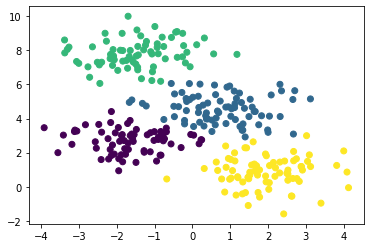

In [9]:
scatter = plt.scatter(X[:,0],X[:,1],
                     c=kmeans_cluster_labels)

In [8]:
gm = GaussianMixture(n_components=4)
gm.fit(X)
gm_cluster_labels = gm.predict(X)


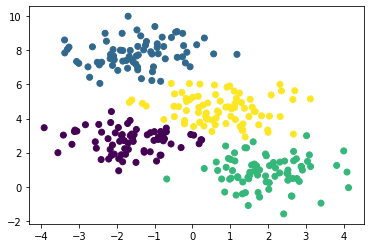

In [10]:
scatter = plt.scatter(X[:,0],X[:,1],
                     c=gm_cluster_labels)

In [11]:
db = DBSCAN(eps=0.78, min_samples=15)
db.fit(X)
db_cluster_labels = db.fit_predict(X)

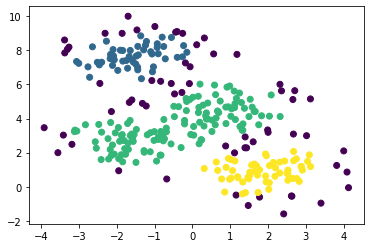

In [12]:
scatter = plt.scatter(X[:,0],X[:,1],
                     c=db_cluster_labels)

In [13]:
ac = AgglomerativeClustering(n_clusters=4)
ac.fit(X)
ac_cluster_labels = ac.fit_predict(X)

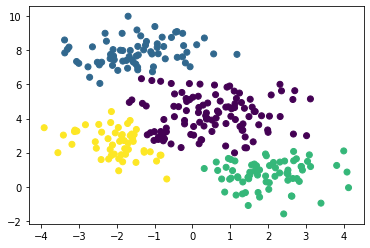

In [14]:
scatter = plt.scatter(X[:,0],X[:,1],
                     c=ac_cluster_labels)

In [17]:
data = pd.read_csv("Mall_Customers.csv")
data = data.iloc[:,3:5]
data.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


C:\Users\Asus\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


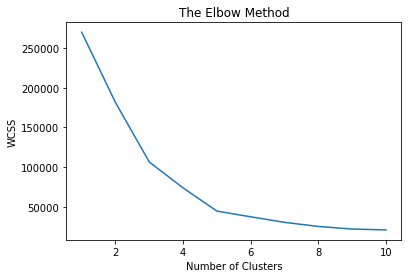

In [18]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans = kmeans.fit(data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

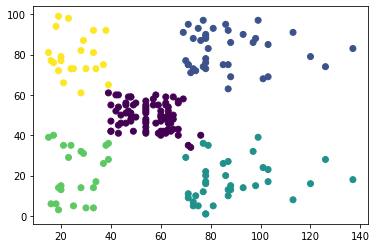

In [19]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data)
labels=kmeans.predict(data)
plt.scatter(data.values[:,0],data.values[:,1],
            c=labels)